# Data Size Impact Study
**Course**: CS 3402

This study investigates how the size of training data influences the performance of Classical ML models versus Artificial Neural Networks (ANNs).

### Data Download Instructions
Please download the following datasets from Kaggle and place the CSV files in the same directory as this notebook (or in a subfolder named `data/`).

1. **Credit Card Approval**: [Rikdifos Dataset](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)
   * Need: `application_record.csv` and `credit_record.csv`.
2. **Student Placement**: [Sehaj Dataset](https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026)
   * Need: `student_placement_prediction_dataset_2026.csv`.
3. **Digital Distraction**: [Neurocipher Dataset](https://www.kaggle.com/datasets/neurocipher/digital-distraction-vs-academic-performance)
   * Need: CSV file (e.g., `student_digital_life.csv` or similar).
4. **Adult Census Income**: [Census Dataset](https://www.kaggle.com/datasets/uciml/adult-census-income)
   * Need: CSV file (`adult.csv`)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Preprocessing

In [21]:
LIMIT_RECORDS = None

def find_path(filename):
    if os.path.exists(filename): return filename
    alt = os.path.join('data', filename)
    if os.path.exists(alt): return alt
    return None

def find_by_keywords(keywords):
    for folder in ['.', 'data']:
        if not os.path.exists(folder): continue
        for f in os.listdir(folder):
            if all(kw.lower() in f.lower() for kw in keywords) and f.endswith('.csv'):
                return os.path.join(folder, f)
    return None

def identify_target(df, keywords, default):
    for col in df.columns:
        if any(kw.lower() in col.lower() for kw in keywords):
            return col
    return default

datasets = {}
print("Searching for datasets...")

# 1. Credit Card (Classification)
app_path = find_path('application_record.csv')
credit_path = find_path('credit_record.csv')
if app_path and credit_path:
    print("Found Credit Card dataset.")
    app_df = pd.read_csv(app_path, nrows=LIMIT_RECORDS)
    credit_df = pd.read_csv(credit_path)
    credit_df['target'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['1','2','3','4','5'] else 0)
    target_agg = credit_df.groupby('ID')['target'].max().reset_index()

    datasets['Credit Card'] = {
        'df': pd.merge(app_df, target_agg, on='ID', how='inner'),
        'task': 'classification',
        'target': 'target'
    }
else:
    print("MISSING: Credit Card dataset")

# 2. Adult Income (Classification)
adult_path = find_path('adult.csv')
if adult_path:
    print(f"Found Adult dataset: {adult_path}")
    df = pd.read_csv(adult_path, nrows=LIMIT_RECORDS)

    target = 'income'

    df[target] = (
        df[target]
        .astype(str)
        .str.strip()
        .str.replace('.', '', regex=False)
        .map({
            '<=50K': 0,
            '>50K': 1
        })
    )

    df = df.dropna(subset=[target])

    datasets['Adult Income'] = {
        'df': df,
        'task': 'classification',
        'target': target
    }

    print(f"  Using target column: {target}")
    print(df[target].value_counts(normalize=True))

else:
    print("MISSING: Adult dataset")

# 3. Digital Distraction (Regression)
dist_file = find_by_keywords(['digital'])
if dist_file:
    print(f"Found Digital Distraction dataset: {dist_file}")
    df = pd.read_csv(dist_file, nrows=LIMIT_RECORDS)

    target = identify_target(df, ['score','final','exam','performance'], 'final_exam_score')

    datasets['Digital Distraction'] = {
        'df': df,
        'task': 'regression',
        'target': target
    }

    print(f"  Using target column: {target}")

else:
    print("MISSING: Digital Distraction dataset")

Searching for datasets...
Found Credit Card dataset.
Found Adult dataset: data\adult.csv
  Using target column: income
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64
Found Digital Distraction dataset: data\student_digital_life.csv
  Using target column: final_exam_score


## 2. Exploratory Data Analysis (EDA)

In [22]:
for name, data in datasets.items():
    print(f"\n-- EDA for {name} --")
    display(data['df'].head(3))
    print(f"Loaded Samples: {len(data['df'])}")


-- EDA for Credit Card --


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0


Loaded Samples: 36457

-- EDA for Adult Income --


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,0


Loaded Samples: 32561

-- EDA for Digital Distraction --


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14


Loaded Samples: 15000


## 3. Pipeline Setup

In [23]:
def create_pipeline(X, model):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    return Pipeline([('pre', preprocessor), ('m', model)])

## 4. Experiment Loop

In [24]:
results = []
fractions = [0.1, 0.3, 0.5, 1.0]
seeds = [42, 123, 999]

from sklearn.metrics import (
    accuracy_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

for name, info in datasets.items():
    print(f"\nRunning Experiment: {name}...")

    df = info['df'].copy()
    target = info['target']

    if target not in df.columns:
        print(f"  ERROR: Target '{target}' not found in {name}")
        continue

    df = df.dropna(subset=[target])

    num_cols = df.select_dtypes(include=['number']).columns.drop(target)
    df[num_cols] = df[num_cols].fillna(0)

    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna('unknown')

    X = df.drop(columns=[target, 'salary_package_lpa'], errors='ignore').copy()
    y = df[target].copy()

    if info['task'] == 'classification':
        y = y.astype(int)
        print(f"  Class distribution:\n{y.value_counts(normalize=True)}")
    else:
        y = pd.to_numeric(y, errors='coerce')

    X = pd.get_dummies(X)

    if len(X) == 0:
        print("  ERROR: No samples remaining after preprocessing.")

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if info['task'] == 'classification' else None
    )

    # --- Models ---
    if info['task'] == 'classification':
        models = {
            'Logistic Regression': LogisticRegression(max_iter=500),
            'MLP (ANN)': MLPClassifier(
                hidden_layer_sizes=(64,32),
                alpha=0.005,
                early_stopping=True,
                max_iter=500,
                random_state=42
            )
        }
    else:
        models = {
            'Ridge': Ridge(),
            'MLP (ANN)': MLPRegressor(
                hidden_layer_sizes=(16,),
                alpha=0.01,
                max_iter=500,
                random_state=42
            )
        }

    for m_name, model in models.items():
        print(f"  Training {m_name}...")

        for frac in fractions:
            test_scores = []
            train_scores = []
            f1_scores = []
            mae_scores = []
            r2_scores = []
            cm = None

            for seed in seeds:

                # --- Subsample ---
                if frac < 1.0:
                    X_sub, _, y_sub, _ = train_test_split(
                        X_train_full, y_train_full,
                        train_size=frac,
                        random_state=seed,
                        stratify=y_train_full if info['task'] == 'classification' else None
                    )
                else:
                    X_sub, y_sub = X_train_full, y_train_full

                # --- Scaling ---
                if 'MLP' in m_name:
                    scaler = StandardScaler()
                    X_sub = scaler.fit_transform(X_sub)
                    X_test_use = scaler.transform(X_test)
                else:
                    X_test_use = X_test

                # --- Train ---
                model.fit(X_sub, y_sub)

                # --- Predictions ---
                test_preds = model.predict(X_test_use)
                train_preds = model.predict(X_sub)

                # --- Metrics ---
                if info['task'] == 'classification':
                    test_acc = accuracy_score(y_test, test_preds)
                    train_acc = accuracy_score(y_sub, train_preds)

                    test_scores.append(test_acc)
                    train_scores.append(train_acc)

                    f1_scores.append(f1_score(y_test, test_preds))

                    if seed == seeds[-1]:
                        cm = confusion_matrix(y_test, test_preds)

                else:
                    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
                    train_rmse = np.sqrt(mean_squared_error(y_sub, train_preds))

                    test_scores.append(test_rmse)
                    train_scores.append(train_rmse)

                    mae_scores.append(mean_absolute_error(y_test, test_preds))
                    r2_scores.append(r2_score(y_test, test_preds))

            # --- Store results ---
            if len(test_scores) > 0:
                results.append({
                    'Dataset': name,
                    'Model': m_name,
                    'Fraction': frac,
                    'Samples': len(X_sub),
                    'Test Mean': np.mean(test_scores),
                    'Train Mean': np.mean(train_scores),
                    'Gap': np.mean(train_scores) - np.mean(test_scores),
                    'Std': np.std(test_scores),
                    'F1 Mean': np.mean(f1_scores) if info['task'] == 'classification' else None,
                    'MAE Mean': np.mean(mae_scores) if info['task'] == 'regression' else None,
                    'R2 Mean': np.mean(r2_scores) if info['task'] == 'regression' else None,
                    'Confusion Matrix': cm if info['task'] == 'classification' else None,
                    'Task': info['task']
                })

results_df = pd.DataFrame(results)


Running Experiment: Credit Card...
  Class distribution:
target
0    0.8823
1    0.1177
Name: proportion, dtype: float64
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Adult Income...
  Class distribution:
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Digital Distraction...
  Training Ridge...
  Training MLP (ANN)...


## 5. Visualization

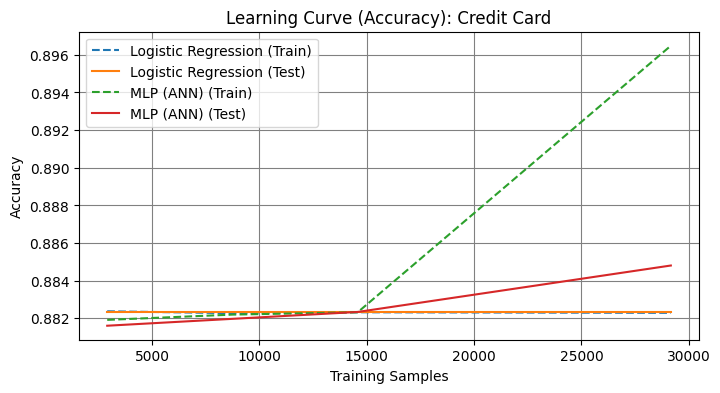

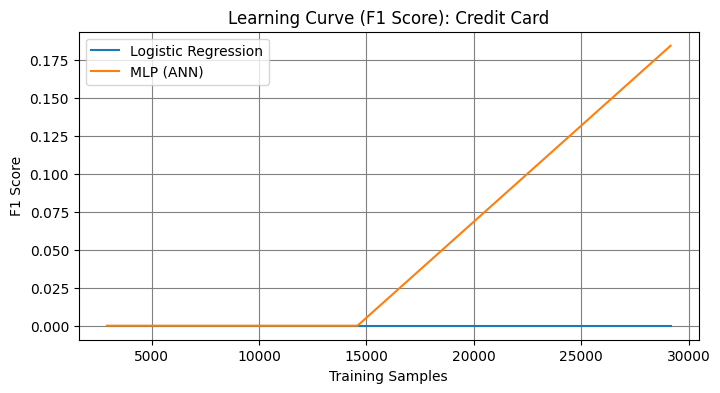

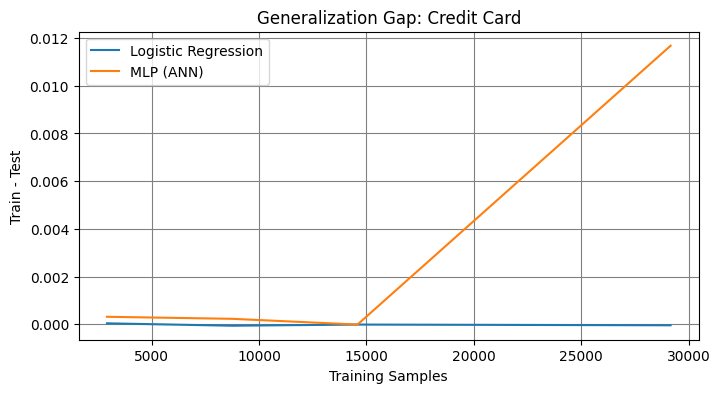

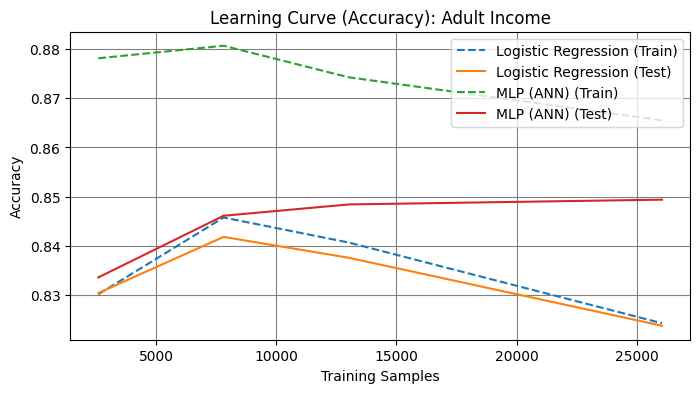

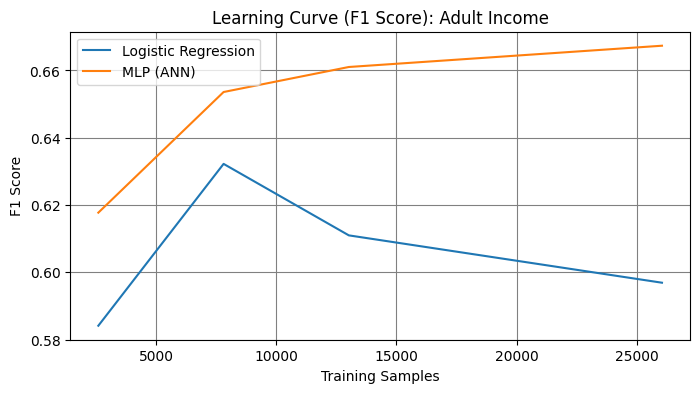

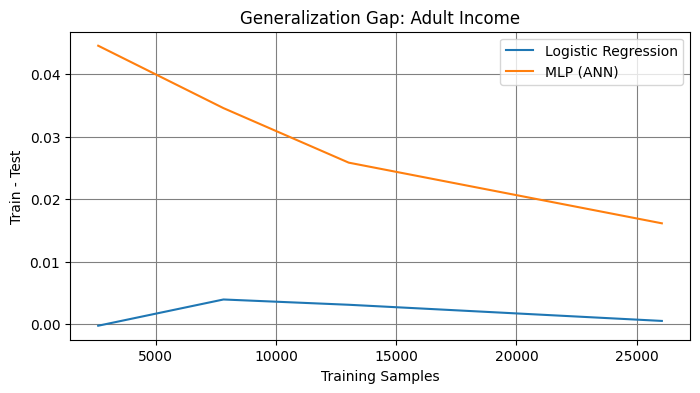

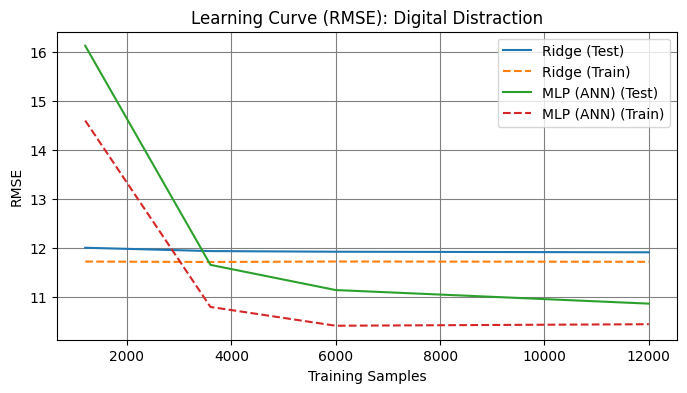

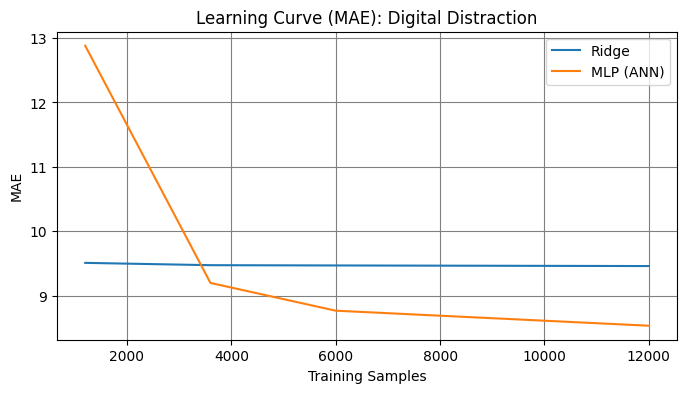

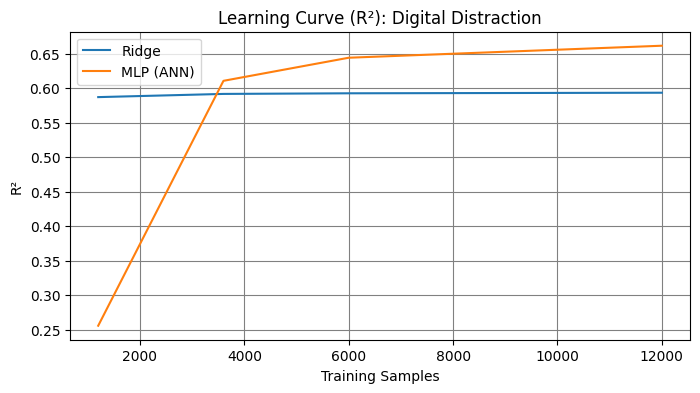

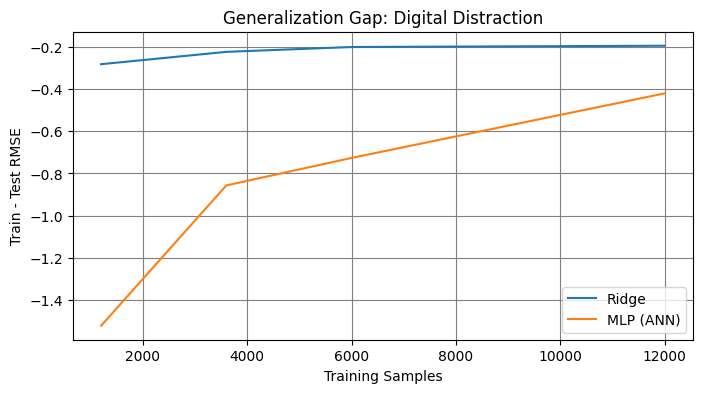

In [25]:
plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': 'gray'
})
if not results_df.empty:
    for name in results_df['Dataset'].unique():
        sub = results_df[results_df['Dataset'] == name]
        task = sub['Task'].iloc[0]

        # --- CLASSIFICATION ---
        if task == 'classification':

            # Accuracy (train vs test)
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['Train Mean'], '--', label=f"{m} (Train)")
                plt.plot(m_sub['Samples'], m_sub['Test Mean'], label=f"{m} (Test)")
            plt.title(f"Learning Curve (Accuracy): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.grid(True)
            plt.show()

            # F1
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['F1 Mean'], label=m)
            plt.title(f"Learning Curve (F1 Score): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("F1 Score")
            plt.legend()
            plt.grid(True)
            plt.show()

            # Generalization Gap
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['Gap'], label=m)
            plt.title(f"Generalization Gap: {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("Train - Test")
            plt.legend()
            plt.grid(True)
            plt.show()

        # --- REGRESSION ---
        else:

            # RMSE
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['Test Mean'], label=f"{m} (Test)")
                plt.plot(m_sub['Samples'], m_sub['Train Mean'], '--', label=f"{m} (Train)")
            plt.title(f"Learning Curve (RMSE): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("RMSE")
            plt.legend()
            plt.grid(True)
            plt.show()

            # MAE
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['MAE Mean'], label=m)
            plt.title(f"Learning Curve (MAE): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("MAE")
            plt.legend()
            plt.grid(True)
            plt.show()

            # R2
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['R2 Mean'], label=m)
            plt.title(f"Learning Curve (R²): {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("R²")
            plt.legend()
            plt.grid(True)
            plt.show()

            # Gap
            plt.figure(figsize=(8, 4))
            for m in sub['Model'].unique():
                m_sub = sub[sub['Model'] == m]
                plt.plot(m_sub['Samples'], m_sub['Gap'], label=m)
            plt.title(f"Generalization Gap: {name}")
            plt.xlabel("Training Samples")
            plt.ylabel("Train - Test RMSE")
            plt.legend()
            plt.grid(True)
            plt.show()